###  **Seção 1: Otimização de Portfólio com Matriz de Covariância e Restrição de Cardinalidade**

A otimização de portfólio é uma ferramenta usada para decidir **como alocar capital entre diferentes ativos financeiros**, de forma a **maximizar o retorno esperado** e **minimizar o risco total do portfólio**.

---

####  **Objetivo do Problema**

Queremos encontrar a melhor combinação de ativos que:
- Tenha **alto retorno esperado**
- Tenha **baixo risco** (considerando a covariância entre os ativos)
- Respeite **restrições de alocação realistas**, como escolher **somente K ativos**

---

####  **Entendendo as Variáveis**

Vamos usar um exemplo com **4 ativos**:

1. **Apple (AAPL)**
2. **Google (GOOGL)**
3. **Amazon (AMZN)**
4. **Tesouro Direto (TD)** (renda fixa)

Para cada ativo nós temos :

$$
\mu_i = \text{retorno médio anual esperado do ativo } i \\
\sigma_i = \text{desvio padrão (volatilidade) do ativo } i \\
\rho_{i,j} = \text{correlação entre os ativos } i \text{ e } j \\
w_i = \text{peso (proporção do capital) investido no ativo } i
$$

Onde a soma dos pesos deve ser 100%:

$$
\sum_{i=1}^{n} w_i = 1
$$



| Ativo  | Retorno Esperado (μ) | Desvio Padrão (σ) |
|--------|-----------------------|--------------------|
| AAPL   | 0.12                  | 0.20               |
| GOOGL  | 0.10                  | 0.18               |
| AMZN   | 0.14                  | 0.25               |
| TD     | 0.05                  | 0.05               |

Correlação entre os ativos:

| Par de Ativos     | Correlação (ρ) |
|-------------------|----------------|
| AAPL & GOOGL      | 0.80           |
| AAPL & AMZN       | 0.75           |
| AAPL & TD         | 0.10           |
| GOOGL & AMZN      | 0.65           |
| GOOGL & TD        | 0.15           |
| AMZN & TD         | 0.20           |

---

####  **Passo a Passo: Construção da Matriz de Covariância**

A matriz de covariância é calculada com:

$$
\Sigma_{i,j} = \rho_{i,j} \cdot \sigma_i \cdot \sigma_j
$$

Substituindo os valores:

$$
\Sigma_{\text{AAPL, AAPL}} = 0.20^2 = 0.0400 \\
\Sigma_{\text{AAPL, GOOGL}} = 0.80 \cdot 0.20 \cdot 0.18 = 0.0288 \\
\Sigma_{\text{AAPL, AMZN}} = 0.75 \cdot 0.20 \cdot 0.25 = 0.0375 \\
\Sigma_{\text{AAPL, TD}} = 0.10 \cdot 0.20 \cdot 0.05 = 0.0010 \\
\Sigma_{\text{GOOGL, GOOGL}} = 0.18^2 = 0.0324 \\
\Sigma_{\text{GOOGL, AMZN}} = 0.65 \cdot 0.18 \cdot 0.25 = 0.02925 \\
\Sigma_{\text{GOOGL, TD}} = 0.15 \cdot 0.18 \cdot 0.05 = 0.00135 \\
\Sigma_{\text{AMZN, AMZN}} = 0.25^2 = 0.0625 \\
\Sigma_{\text{AMZN, TD}} = 0.20 \cdot 0.25 \cdot 0.05 = 0.0025 \\
\Sigma_{\text{TD, TD}} = 0.05^2 = 0.0025
$$

A matriz de covariância final será:

|         | AAPL   | GOOGL  | AMZN   | TD     |
|---------|--------|--------|--------|--------|
| **AAPL**  | 0.0400 | 0.0288 | 0.0375 | 0.0010 |
| **GOOGL** | 0.0288 | 0.0324 | 0.0293 | 0.0014 |
| **AMZN**  | 0.0375 | 0.0293 | 0.0625 | 0.0025 |
| **TD**    | 0.0010 | 0.0014 | 0.0025 | 0.0025 |

---

#### **Passo a Passo: Cálculo do Retorno Esperado**

Exemplo de alocação:

$$
w_{\text{AAPL}} = 0.3, \quad w_{\text{GOOGL}} = 0.2, \quad w_{\text{AMZN}} = 0.4, \quad w_{\text{TD}} = 0.1
$$

Com isso:

$$
E[R_p] = (0.3 \cdot 0.12) + (0.2 \cdot 0.10) + (0.4 \cdot 0.14) + (0.1 \cdot 0.05) = 0.117 \Rightarrow 11.7\%
$$

---

#### **Passo a Passo: Cálculo do Risco com a Matriz de Covariância**

$$
\sigma_p^2 = \mathbf{w}^T \cdot \Sigma \cdot \mathbf{w}
$$

Substituindo a matriz e o vetor de pesos, temos:

$$
\sigma_p^2 = 
(0.3, 0.2, 0.4, 0.1)
\begin{bmatrix}
0.0400 & 0.0288 & 0.0375 & 0.0010 \\
0.0288 & 0.0324 & 0.0293 & 0.0014 \\
0.0375 & 0.0293 & 0.0625 & 0.0025 \\
0.0010 & 0.0014 & 0.0025 & 0.0025
\end{bmatrix}
\begin{bmatrix}
0.3 \\
0.2 \\
0.4 \\
0.1
\end{bmatrix}
$$

Resultado:

$$
\sigma_p^2 \approx 0.03371 \quad \Rightarrow \quad \sigma_p \approx 18.36\%
$$

---

####  **Passo a Passo: Cálculo do Índice de Sharpe**

Assumindo taxa livre de risco \( R_f = 3\% = 0.03 \):

$$
SR = \frac{E[R_p] - R_f}{\sigma_p} = \frac{0.117 - 0.03}{0.1836} \approx 0.474
$$

---

#### **Restrição de Cardinalidade (K ativos)**

Na prática, é comum limitar o número de ativos no portfólio (ex: no máximo 10). Isso evita carteiras com muitos ativos irrelevantes.

Como o framework `CUSTOMHyS` trabalha apenas com variáveis contínuas, utilizaremos uma **heurística**:

- Geramos um vetor contínuo de pesos.
- Selecionamos os **K ativos com maiores pesos**.
- Zeros nos demais, e normalizamos os K pesos selecionados para somar 1.

---

#### **Fronteira Eficiente e Avaliação das Heurísticas**

A **Fronteira Eficiente Não Restrita (UEF)** representa todas as combinações de portfólio que **maximizam o retorno para um dado nível de risco** ou **minimizam o risco para um dado retorno**, **sem restrições de cardinalidade**.

No artigo de Chang et al. (2000), essa fronteira foi obtida por métodos exatos de otimização convexa e depois **salva em arquivos como `portef1`, `portef2` etc.** com pares 
$$
(\mu, \sigma^2)
$$
 para permitir **comparação com soluções heurísticas**.

Para avaliar a qualidade de uma solução com restrição de cardinalidade (obtida por heurística), os autores projetaram essa solução sobre a UEF. Isso foi feito por meio de interpolação linear entre os pontos da fronteira eficiente, permitindo encontrar a solução teórica mais próxima que apresenta o mesmo nível de risco ou retorno.
---

####  **O que é a Fronteira Eficiente?**

A Fronteira Eficiente é o **conjunto de portfólios ótimos**, ou seja, aqueles que:
- **Têm o menor risco possível** para um dado nível de retorno
- **Têm o maior retorno possível** para um dado nível de risco

Ela é representada graficamente por uma **curva convexa ascendente** no plano **risco × retorno**.

Imagine um gráfico com:
- Eixo X = risco (desvio padrão)
- Eixo Y = retorno esperado

A Fronteira Eficiente é a **borda superior da nuvem de pontos possíveis**, formando uma curva como essa:
#####  **Exemplo Prático**

Vamos supor que temos 1000 combinações aleatórias de portfólios feitos a partir dos ativos:
- AAPL (12%, 20%)
- GOOGL (10%, 18%)
- AMZN (14%, 25%)
- TD (5%, 5%)

Calculamos o retorno e risco de cada portfólio e traçamos todos esses pontos no plano:

$$
(\sigma, \mu)
$$

A **Fronteira Eficiente** será formada pelos **pontos mais ao norte e à esquerda** da nuvem.

Essa curva pode ser calculada resolvendo uma sequência de problemas de otimização para diferentes níveis de retorno (ou diferentes pesos):

$$
\lambda
$$

Quanto mais pontos usarmos, mais suave e precisa será a curva.

<img src=image.png alt="Fronteira Eficiente" width="45%"/>

---


####  **Métrica de Avaliação das Heurísticas**

A partir da curva UEF, os autores do artigo definiram as métricas:

- **Erro percentual na direção do risco**:

$$
\text{Erro}_{\text{risco}} = 100 \times \frac{\sigma^* - \sigma^{**}}{\sigma^{**}}
$$

- **Erro percentual na direção do retorno**:

$$
\text{Erro}_{\text{retorno}} = 100 \times \frac{\mu^* - \mu^{**}}{\mu^{**}}
$$

Onde:

$$
\begin{aligned}
(\mu^*, \sigma^*) &\text{ — solução encontrada pela heurística} \\
(\mu^{**}, \sigma^{**}) &\text{ — projeção correspondente na UEF}
\end{aligned}
$$

A **métrica final** adotada é o menor dos dois erros:

$$
\text{Erro final} = \min(\text{Erro}_{\text{risco}}, \text{Erro}_{\text{retorno}})
$$

Essa abordagem permite **comparar diretamente** o desempenho das heurísticas contra a fronteira ideal de mercado — uma métrica que é ao mesmo tempo quantitativa, interpretável e prática para aplicações científicas.

---

Essa abordagem nos permite **simular o comportamento do problema original com restrição de cardinalidade**, usando apenas variáveis contínuas. A próxima seção demonstrará isso na prática.



### 📊 **Seção 2: Resolvendo o problema com o customhys**

#### Instalando o package e baixando do github
 Utilize caso não esteja em um ambiente com o package instalado, como o google colab

In [34]:
# Clonar rep
# !git clone https://github.com/jcrvz/customhys.git .
# Instalar as dependências
# !pip install -r requirements.txt

# Instalar o CUSTOMHyS como pacote
# !pip install .
# %cd customhys
# %cd customhys

#### Função para ler instâncias OR-Library
Funções que leem instâncias que estão no formato OR-Library para o problema do portfólio single period

In [44]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt




def read_or_library_instance(filepath):
    """
    Lê um arquivo de instância da OR-Library (ex: port1.txt) e retorna:
    - número de ativos
    - retornos esperados (μ_i)
    - desvios padrão (σ_i)
    - matriz de correlação (ρ_{i,j})
    - matriz de covariância (Σ)
    - dataframe da covariância para visualização
    """

    # Abre e lê todas as linhas do arquivo
    with open(filepath, 'r') as file:
        lines = file.readlines()

    # Número total de ativos financeiros disponíveis na instância
    n_assets = int(lines[0].strip())

    # Lê os retornos esperados e os desvios padrão (μ_i e σ_i)
    returns = []
    std_devs = []
    for i in range(1, n_assets + 1):
        mu, sigma = map(float, lines[i].strip().split())
        returns.append(mu)
        std_devs.append(sigma)

    # Inicializa a matriz de correlação com 1's na diagonal principal
    corr_matrix = np.eye(n_assets)

    # Lê os pares de ativos e suas respectivas correlações ρ_{i,j}
    for line in lines[n_assets + 1:]:
        i, j, rho = line.strip().split()
        i, j = int(i) - 1, int(j) - 1  # Corrige índice (de 1-based para 0-based)
        rho = float(rho)
        corr_matrix[i][j] = rho
        corr_matrix[j][i] = rho  # Simetria da matriz

    # Constrói a matriz de covariância Σ com:
    # Σ_{i,j} = ρ_{i,j} * σ_i * σ_j
    sigma_array = np.array(std_devs)
    cov_matrix = np.outer(sigma_array, sigma_array) * corr_matrix

    # Cria um DataFrame para visualização fácil da matriz de covariância
    df_cov = pd.DataFrame(
        cov_matrix,
        columns=[f"Asset {i+1}" for i in range(n_assets)],
        index=[f"Asset {i+1}" for i in range(n_assets)]
    )

    # Retorna um dicionário com todos os dados necessários
    return {
        "n_assets": n_assets,
        "returns": np.array(returns),         # Vetor de retornos esperados μ_i
        "std_devs": np.array(std_devs),       # Vetor de desvios padrão σ_i
        "corr_matrix": corr_matrix,           # Matriz de correlação ρ_{i,j}
        "cov_matrix": cov_matrix,             # Matriz de covariância Σ
        "df_cov": df_cov                      # DataFrame para visualização
    }


In [36]:
# Lê o arquivo port1 para testar
instance_data = read_or_library_instance("port1.txt")

print("\nMatriz de Covariância\n")
display(instance_data["df_cov"].round(5))  # Arredondando para facilitar a leitura


Matriz de Covariância



,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9,Asset 10,...,Asset 22,Asset 23,Asset 24,Asset 25,Asset 26,Asset 27,Asset 28,Asset 29,Asset 30,Asset 31
Asset 1,0.00187,0.00098,0.00133,0.00137,0.00100,0.00163,0.00137,0.00124,0.00088,0.00147,...,0.00089,0.00133,0.00151,0.00162,0.00061,0.00140,0.00041,0.00084,0.00081,0.00082
Asset 2,0.00098,0.00162,0.00104,0.00103,0.00130,0.00113,0.00108,0.00101,0.00092,0.00107,...,0.00083,0.00107,0.00120,0.00134,0.00064,0.00115,0.00037,0.00080,0.00079,0.00072
Asset 3,0.00133,0.00104,0.00171,0.00141,0.00097,0.00155,0.00140,0.00128,0.00111,0.00144,...,0.00094,0.00140,0.00154,0.00169,0.00057,0.00146,0.00043,0.00092,0.00089,0.00087
Asset 4,0.00137,0.00103,0.00141,0.00202,0.00118,0.00171,0.00156,0.00144,0.00123,0.00153,...,0.00102,0.00170,0.00182,0.00177,0.00065,0.00152,0.00049,0.00096,0.00095,0.00092
Asset 5,0.00100,0.00130,0.00097,0.00118,0.00478,0.00127,0.00121,0.00116,0.00117,0.00106,...,0.00071,0.00130,0.00118,0.00138,0.00055,0.00130,0.00042,0.00064,0.00088,0.00063
Asset 6,0.00163,0.00113,0.00155,0.00171,0.00127,0.00288,0.00174,0.00156,0.00124,0.00186,...,0.00117,0.00175,0.00192,0.00194,0.00072,0.00174,0.00068,0.00111,0.00107,0.00102
Asset 7,0.00137,0.00108,0.00140,0.00156,0.00121,0.00174,0.00217,0.00146,0.00114,0.00173,...,0.00108,0.00157,0.00179,0.00179,0.00083,0.00179,0.00064,0.00104,0.00099,0.00103
Asset 8,0.00124,0.00101,0.00128,0.00144,0.00116,0.00156,0.00146,0.00207,0.00127,0.00138,...,0.00101,0.00167,0.00155,0.00162,0.00063,0.00148,0.00052,0.00101,0.00094,0.00095
Asset 9,0.00088,0.00092,0.00111,0.00123,0.00117,0.00124,0.00114,0.00127,0.00288,0.00106,...,0.00071,0.00127,0.00121,0.00129,0.00045,0.00120,0.00048,0.00082,0.00071,0.00082
Asset 10,0.00147,0.00107,0.00144,0.00153,0.00106,0.00186,0.00173,0.00138,0.00106,0.00220,...,0.00111,0.00152,0.00187,0.00179,0.00061,0.00165,0.00068,0.00107,0.00098,0.00099


#### Criando função de avaliação

In [37]:
# Variaveis para acompanhar a execução
execution_logs = []  # Lista para armazenar os logs de execução

def portfolio_evaluation(weights, instance_data, k=None, risk_free_rate=0.03):
    n = instance_data["n_assets"]
    returns = instance_data["returns"]
    cov = instance_data["cov_matrix"]

    weights = np.array(weights)

    if k is not None and k < n:
        top_indices = np.argsort(weights)[-k:]
        mask = np.zeros_like(weights)
        mask[top_indices] = 1
        weights = weights * mask
        weights /= weights.sum() if weights.sum() != 0 else 1
    else:
        weights /= weights.sum() if weights.sum() != 0 else 1

    expected_return = np.dot(weights, returns)
    variance = np.dot(weights, np.dot(cov, weights))
    risk = np.sqrt(variance)
    sharpe = (expected_return - risk_free_rate) / risk if risk > 0 else -1e6

    execution_log = {
        "execution_number": len(execution_logs) + 1,
        "weights": weights.copy(),
        "selected_assets": np.where(weights > 0)[0].tolist(),
        "expected_return": expected_return,
        "risk": risk,
        "sharpe": sharpe
    }

    # Adiciona o log ao histórico
    execution_logs.append(execution_log)

    return -sharpe, execution_log


##### Testando no portifólio de 4 ativos

In [38]:

# Exemplo de teste rápido
from_port1 = {
    "n_assets": 4,
    "returns": np.array([0.12, 0.10, 0.14, 0.05]),
    "cov_matrix": np.array([
        [0.0400, 0.0288, 0.0375, 0.0010],
        [0.0288, 0.0324, 0.0293, 0.0014],
        [0.0375, 0.0293, 0.0625, 0.0025],
        [0.0010, 0.0014, 0.0025, 0.0025]
    ])
}

# Executa a função
resultado, log = portfolio_evaluation([0.3, 0.2, 0.4, 0.1], from_port1, k=2, risk_free_rate=0.03)

# Visualiza
df_log = pd.DataFrame([log])
display(df_log[["execution_number","weights", "selected_assets", "expected_return", "risk", "sharpe"]].round(5))

,execution_number,weights,selected_assets,expected_return,risk,sharpe
0,1,"[0.4285714285714286, 0.0, 0.5714285714285715, ...","[0, 2]",0.13143,0.21476,0.47228


#### Função para criar problema no formato que a hyperheuristica aceita, utilizando os probelmas já definidos acima

In [39]:
def configure_problem(instance_data, k=None, risk_free_rate=0.03):
    """
    Configura o problema no formato aceito pelo CUSTOMHyS.
    
    Parâmetros:
    - instance_data: dicionário retornado por read_or_library_instance()
    - k: restrição de cardinalidade (número máximo de ativos)
    - risk_free_rate: taxa livre de risco

    Retorna:
    - dicionário com as chaves esperadas por CUSTOMHyS
    """
    n = instance_data["n_assets"]
    lower_bounds = [0.0] * n
    upper_bounds = [1.0] * n

    return {
        "function": lambda weights: portfolio_evaluation(weights, instance_data, k=k, risk_free_rate=risk_free_rate)[0],
        "is_constrained": True,
        "boundaries": (lower_bounds, upper_bounds)
    }

##### Exemplo de uso

In [40]:
# Carrega os dados da instância da OR-Library
instance_data = read_or_library_instance("port1.txt")

# Prepara o problema para o CUSTOMHyS com restrição de 10 ativos
problem_config = configure_problem(instance_data, k=10)

# Verifica estrutura
import json
print(json.dumps(problem_config, indent=2, default=str))

{
  "function": "<function configure_problem.<locals>.<lambda> at 0x0000022DE93AA520>",
  "is_constrained": true,
  "boundaries": [
    [
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0
    ],
    [
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0
    ]
  ]
}


#### Configração de parametros para a hyperheuristica


In [64]:
# 🔹 Configuração dos parâmetros da Hyper-Heurística
hh_config = {
    "cardinality": 10,  # Máximo de operadores na sequência
    "cardinality_min": 1,  # Mínimo de operadores na sequência
    "num_iterations": 100,  # Número de iterações
    "num_agents": 30,  # Tamanho da população
    "as_mh": False,  # Usa a sequência de HH como uma metaheurística completa?
    "num_replicas": 20,  # Número de réplicas por MH
    "num_steps": 100,  # Número de tentativas por passo da HH
    "stagnation_percentage": 0.40,  # Percentual de estagnação para controle
    "max_temperature": 1,  # Temperatura inicial (Simulated Annealing)
    "min_temperature": 1e-6,  # Temperatura mínima (Simulated Annealing)
    "cooling_rate": 1e-3,  # Taxa de resfriamento (Simulated Annealing)
    "temperature_scheme": "fast",  # Esquema de temperatura
    "acceptance_scheme": "exponential",  # Critério de aceitação de soluções
    "allow_weight_matrix": True,  # Permite matriz de pesos
    "trial_overflow": False,  # Política de overflow de tentativas
    "repeat_operators": True,  # Permite repetição de operadores na sequência
    "verbose": False,  # Exibir logs e progresso
    "learning_portion": 0.5,  # Percentual de aprendizado das sequências
    "solver": "static",  # Tipo de solver
}

##### Confirmando configurações 

In [42]:
import json

print("\n🔍 [LOG] Estrutura do Problema antes da Hyper-Heurística:")
print(json.dumps(problem_config, indent=4, default=str))  # Imprime o dicionário do problema de forma legível
print("\n🔍 [LOG] Configuração da Hyper-Heurística:")
print(json.dumps(hh_config, indent=4, default=str))



🔍 [LOG] Estrutura do Problema antes da Hyper-Heurística:
{
    "function": "<function configure_problem.<locals>.<lambda> at 0x0000022DE93AA520>",
    "is_constrained": true,
    "boundaries": [
        [
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0
        ],
        [
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
            1.0,
         

#### Executando a hyperheuristica

In [65]:
from customhys.hyperheuristic import Hyperheuristic

# 🔹 Criar a instância da Hyper-Heurística
hh = Hyperheuristic(heuristic_space='default.txt', problem=problem_config, parameters=hh_config)

# 🔹 Executar a otimização
print("\n🚀 [LOG] Iniciando execução da Hyper-Heurística...\n")

execution_logs.clear()  # Limpa os logs antigos
cont = 0  # Reinicia o contador de execuções
result = hh.solve()  # Executa a otimização
df_logs = pd.DataFrame(execution_logs)


print("\n🔍 [LOG] Resultado da Hyper-Heurística:", result)
display(df_logs[["selected_assets", "expected_return", "risk", "sharpe"]].round(5))


🚀 [LOG] Iniciando execução da Hyper-Heurística...

[('spiral_dynamic', {'radius': 0.9, 'angle': 22.5, 'sigma': 0.1}, 'all'), ('genetic_crossover', {'pairing': 'cost', 'crossover': 'blend', 'mating_pool_factor': 0.4}, 'greedy'), ('spiral_dynamic', {'radius': 0.9, 'angle': 22.5, 'sigma': 0.1}, 'greedy'), ('genetic_crossover', {'pairing': 'rank', 'crossover': 'blend', 'mating_pool_factor': 0.4}, 'all'), ('swarm_dynamic', {'factor': 1.0, 'self_conf': 2.54, 'swarm_conf': 2.56, 'version': 'constriction', 'distribution': 'levy'}, 'probabilistic'), ('differential_mutation', {'expression': 'rand-to-best-and-current', 'num_rands': 1, 'factor': 1.0}, 'greedy'), ('genetic_crossover', {'pairing': 'random', 'crossover': 'blend', 'mating_pool_factor': 0.4}, 'greedy'), ('swarm_dynamic', {'factor': 0.7, 'self_conf': 2.54, 'swarm_conf': 2.56, 'version': 'inertial', 'distribution': 'gaussian'}, 'metropolis'), ('local_random_walk', {'probability': 0.75, 'scale': 1.0, 'distribution': 'gaussian'}, 'probabi

,selected_assets,expected_return,risk,sharpe
0,"[1, 2, 4, 9, 10, 15, 19, 23, 28, 30]",0.00394,0.03435,-0.75866
1,"[2, 4, 7, 8, 10, 11, 12, 14, 22, 27]",0.00467,0.03302,-0.76714
2,"[6, 7, 8, 11, 15, 17, 20, 22, 23, 24]",0.00364,0.03737,-0.70544
3,"[2, 8, 9, 12, 13, 16, 17, 18, 24, 30]",0.00308,0.03611,-0.74539
4,"[3, 5, 7, 9, 14, 20, 21, 23, 27, 29]",0.00311,0.03483,-0.77194
...,...,...,...,...
2013595,"[1, 3, 4, 9, 18, 19, 22, 23, 24, 28]",0.00503,0.03906,-0.63912
2013596,"[3, 4, 7, 9, 13, 18, 19, 22, 23, 26]",0.00496,0.04056,-0.61738
2013597,"[4, 5, 9, 13, 18, 19, 22, 23, 24, 27]",0.00439,0.03941,-0.64971
2013598,"[4, 5, 9, 13, 18, 19, 22, 23, 24, 27]",0.00439,0.03941,-0.64971


### 📌 **Seção 3: Comparando valores encontrados com a Fronteira eficiente**
Nessa seção iremos encontrar o valor ótimo por meio de força bruta, para compararmos com o valor dado pela hyperheuristica

#  Avaliação de Soluções CustomHyS vs Fronteira Eficiente

##  1. Interpolação da Fronteira Eficiente

A fronteira eficiente representa a melhor relação possível entre risco (desvio padrão) e retorno esperado para um portfólio.

```python
interp_return_given_risk = interp1d(...)
interp_risk_given_return = interp1d(...)
```

- `interp_return_given_risk`: cria uma função contínua que, dado um risco (σ), estima o retorno eficiente correspondente.
- `interp_risk_given_return`: cria uma função que, dado um retorno, estima o risco mínimo possível na fronteira eficiente.

Essas funções permitem **comparar soluções obtidas** com a fronteira, mesmo que o ponto exato não esteja nos dados discretos da fronteira.

---

##  2. Aplicação da Interpolação

```python
df_best["interp_ret_from_risk"] = ...
df_best["interp_risk_from_ret"] = ...
```

Para cada uma das melhores soluções da Hyper-Heurística (armazenadas em `df_best`), aplicamos:
- A interpolação do retorno esperado com base no risco calculado.
- A interpolação do risco mínimo com base no retorno observado.

---

## 📉3. Cálculo dos Erros Percentuais

```python
df_best["error_return"] = ...
df_best["error_risk"] = ...
df_best["percent_error"] = ...
```

São calculados dois erros relativos:

- **Erro no Eixo Y (Retorno):**
  \[
  \text{Erro}_{\text{retorno}} = \left| \frac{R_{\text{obtido}} - R_{\text{interp.}}}{R_{\text{interp.}}} \right|
  \]

- **Erro no Eixo X (Risco):**
  \[
  \text{Erro}_{\text{risco}} = \left| \frac{\sigma_{\text{obtido}} - \sigma_{\text{interp.}}}{\sigma_{\text{interp.}}} \right|
  \]

- O **menor entre os dois** é escolhido como o erro percentual total da solução.

---

## 4. Estatísticas dos Erros

```python
mean_error = ...
median_error = ...
```

São exibidos:
- **Erro percentual médio**: média de todos os percentuais de erro.
- **Erro percentual mediano**: valor central da distribuição de erros.

Além disso, os 5 piores casos são mostrados.

---

## 5. Seleção das Melhores Soluções

Três soluções são destacadas:

1. **Melhor Sharpe**: maior razão entre retorno excedente e risco.
2. **Maior Retorno**: solução com o maior retorno absoluto.
3. **Menor Risco**: solução com o menor desvio padrão.

Cada uma tem seus dados exibidos:
- Sharpe
- Retorno Esperado
- Risco (σ)
- Erro Percentual (interp.)
- Ativos selecionados
- Pesos atribuídos

---

##  6. Plotagem Comparativa

São plotados no gráfico:

- 🔵 Fronteira eficiente (pontos azuis)
- 🔴 As 100 melhores soluções da Hyper-Heurística
- ⭐ Melhor solução segundo Sharpe (dourado)
- ✅ Maior retorno (verde)
- 🟣 Menor risco (roxo)

Cada uma das três melhores soluções recebe também um rótulo com a métrica destacada:
- "Sharpe: x.xx"
- "Retorno: x.xx"
- "Risco: x.xx"

---


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\João Neto\AppData\Local\Temp\ipykernel_16604\613594381.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_portef = pd.read_csv(file_path, sep="\s+", header=None, names=["mean_return", "variance"])


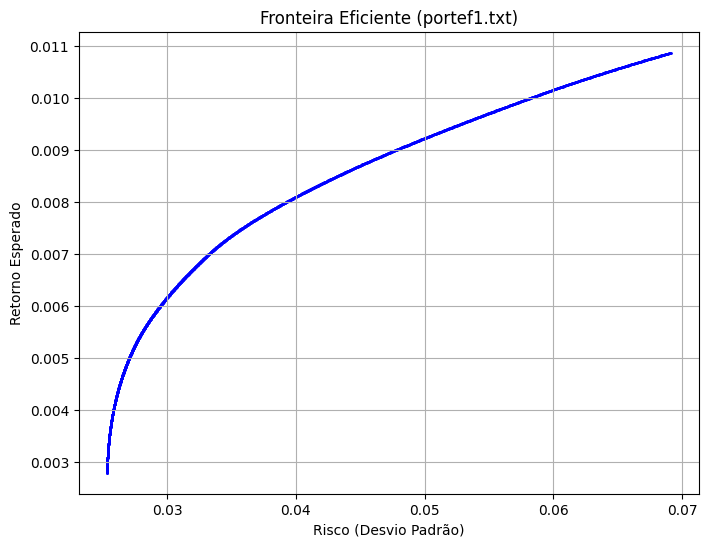

In [59]:
# Carrega os dados da fronteira eficiente
file_path = 'portef1.txt'
df_portef = pd.read_csv(file_path, sep="\s+", header=None, names=["mean_return", "variance"])
df_portef["std_dev"] = np.sqrt(df_portef["variance"])  # Calcula risco (desvio padrão)

# Plota com pontos individuais
plt.figure(figsize=(8, 6))
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=1, color='blue')  # s=10 reduz o tamanho dos pontos
plt.title("Fronteira Eficiente (portef1.txt)")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.show()


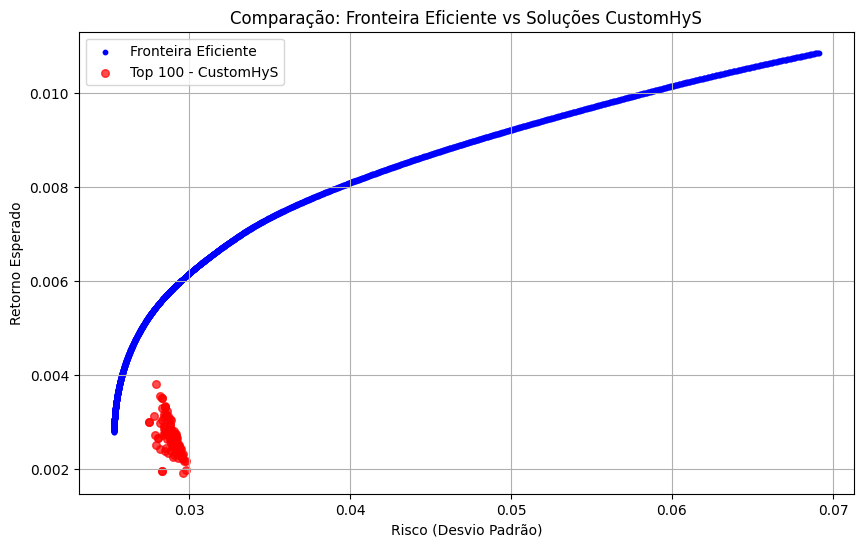

In [69]:
# 3. Seleciona as 100 melhores execuções com base no maior índice de Sharpe
df_best = df_logs.sort_values(by="sharpe", ascending=True).head(100)

# 4. Plotagem comparativa
plt.figure(figsize=(10, 6))

# Fronteira eficiente
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=10, color='blue', label="Fronteira Eficiente")

# Soluções da Hyperheurística
plt.scatter(df_best["risk"], df_best["expected_return"], s=30, color='red', alpha=0.7, label="Top 100 - CustomHyS")

plt.title("Comparação: Fronteira Eficiente vs Soluções CustomHyS")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.legend()
plt.show()


In [68]:
from scipy.interpolate import interp1d

# 1. Cria função de interpolação da fronteira eficiente
interp_frontier = interp1d(
    df_portef["std_dev"], 
    df_portef["mean_return"], 
    kind='linear', 
    bounds_error=False, 
    fill_value="extrapolate"
)

# 2. Aplica a interpolação nos riscos das soluções encontradas
df_best["interpolated_return"] = interp_frontier(df_best["risk"])

# 3. Calcula o erro percentual para cada solução
df_best["percent_error"] = (
    np.abs(df_best["expected_return"] - df_best["interpolated_return"]) 
    / df_best["interpolated_return"]
)

# 4. Exibe estatísticas dos erros
mean_error = df_best["percent_error"].mean()
median_error = df_best["percent_error"].median()

print(f"📉 Erro percentual médio: {mean_error:.4f}%")
print(f"📈 Erro percentual mediano: {median_error:.4f}%")

# (Opcional) Exibe os 5 piores erros
print("\n🚨 Top 5 maiores erros percentuais:")
display(df_best.sort_values(by="percent_error", ascending=False).head(5)[
    ["expected_return", "risk", "interpolated_return", "percent_error"]
])

📉 Erro percentual médio: 0.5370%
📈 Erro percentual mediano: 0.5448%

🚨 Top 5 maiores erros percentuais:


,expected_return,risk,interpolated_return,percent_error
1080231,0.001912,0.029655,0.006052,0.684071
816479,0.001971,0.029784,0.006092,0.676363
1493525,0.001941,0.028323,0.005594,0.652961
1493495,0.001942,0.028320,0.005593,0.652838
1095241,0.002156,0.029673,0.006058,0.644088


📉 Erro percentual médio: 0.1382
📈 Erro percentual mediano: 0.1393

🚨 Top 5 maiores erros percentuais:


,expected_return,risk,interp_ret_from_risk,interp_risk_from_ret,percent_error
1469317,0.002171,0.029798,0.006096,0.025342,0.175853
816479,0.001971,0.029784,0.006092,0.025341,0.175310
1095241,0.002156,0.029673,0.006058,0.025342,0.170924
1080231,0.001912,0.029655,0.006052,0.025341,0.170225
1429086,0.002319,0.029606,0.006037,0.025342,0.168262



🏅 Melhor solução encontrada pela Hyper-Heurística:
Sharpe: -0.9908
Retorno Esperado: 0.0019
Risco (Desvio Padrão): 0.0283
Erro Percentual (interp): 0.1176
Ações Selecionadas (índices): [0, 2, 12, 15, 16, 17, 25, 27, 29, 30]
Pesos: [0.09774814 0.         0.10325476 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.09771332 0.         0.         0.09140957 0.10723597 0.09888399
 0.         0.         0.         0.         0.         0.
 0.         0.09262163 0.         0.10688611 0.         0.10408703
 0.10015949]

📈 Solução com MAIOR RETORNO:
Sharpe: -0.9365
Retorno Esperado: 0.0038
Risco (Desvio Padrão): 0.0280
Erro Percentual (interp): 0.0882
Ações Selecionadas: [1, 8, 12, 14, 16, 19, 25, 27, 28, 29]
Pesos: [0.         0.10740491 0.         0.         0.         0.
 0.         0.         0.08018923 0.         0.         0.
 0.10654726 0.         0.09231731 0.         0.12440341 0.
 0.         0.07804087 0.         0.         0.         0.
 0.     

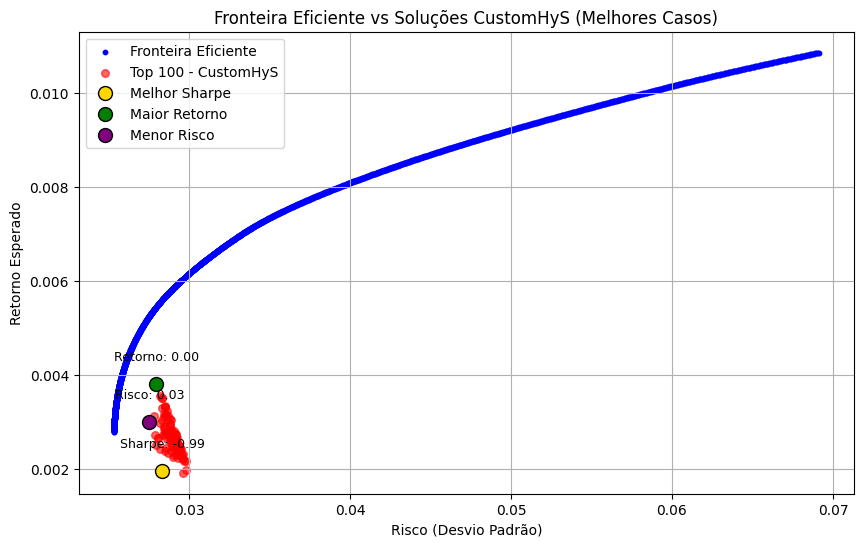

In [75]:
import matplotlib.pyplot as plt

# 1. Funções de interpolação da fronteira eficiente
interp_return_given_risk = interp1d(
    df_portef["std_dev"],
    df_portef["mean_return"],
    kind='linear',
    bounds_error=False,
    fill_value="extrapolate"
)

interp_risk_given_return = interp1d(
    df_portef["mean_return"],
    df_portef["std_dev"],
    kind='linear',
    bounds_error=False,
    fill_value="extrapolate"
)

# 2. Aplica ambas as interpolações para cada ponto da hyperheurística
df_best["interp_ret_from_risk"] = interp_return_given_risk(df_best["risk"])
df_best["interp_risk_from_ret"] = interp_risk_given_return(df_best["expected_return"])

# 3. Calcula os erros percentuais nos dois eixos
df_best["error_return"] = (
    np.abs(df_best["expected_return"] - df_best["interp_ret_from_risk"]) / df_best["interp_ret_from_risk"]
)

df_best["error_risk"] = (
    np.abs(df_best["risk"] - df_best["interp_risk_from_ret"]) / df_best["interp_risk_from_ret"]
)

# 4. Usa o menor erro percentual entre os dois para cada ponto
df_best["percent_error"] = df_best[["error_return", "error_risk"]].min(axis=1)

# 5. Estatísticas dos erros
mean_error = df_best["percent_error"].mean()
median_error = df_best["percent_error"].median()

print(f"📉 Erro percentual médio: {mean_error:.4f}")
print(f"📈 Erro percentual mediano: {median_error:.4f}")

# 6. Mostra os 5 piores casos
print("\n🚨 Top 5 maiores erros percentuais:")
display(df_best.sort_values(by="percent_error", ascending=False).head(5)[[
    "expected_return", "risk", "interp_ret_from_risk", "interp_risk_from_ret", "percent_error"
]])

# 7. Mostra a melhor solução da hyperheurística (menor Sharpe → maior valor numérico negativo)
melhor_solucao = df_best.sort_values(by="sharpe", ascending=True).iloc[0]

print("\n🏅 Melhor solução encontrada pela Hyper-Heurística:")
print(f"Sharpe: {melhor_solucao['sharpe']:.4f}")
print(f"Retorno Esperado: {melhor_solucao['expected_return']:.4f}")
print(f"Risco (Desvio Padrão): {melhor_solucao['risk']:.4f}")
print(f"Erro Percentual (interp): {melhor_solucao['percent_error']:.4f}")
print(f"Ações Selecionadas (índices): {melhor_solucao['selected_assets']}")
print(f"Pesos: {melhor_solucao['weights']}")

# 9. Seleciona também a solução com maior retorno e menor risco
melhor_retorno = df_best.sort_values(by="expected_return", ascending=False).iloc[0]
menor_risco = df_best.sort_values(by="risk", ascending=True).iloc[0]

# 10. Exibe todas as três soluções com informações detalhadas
print("\n📈 Solução com MAIOR RETORNO:")
print(f"Sharpe: {melhor_retorno['sharpe']:.4f}")
print(f"Retorno Esperado: {melhor_retorno['expected_return']:.4f}")
print(f"Risco (Desvio Padrão): {melhor_retorno['risk']:.4f}")
print(f"Erro Percentual (interp): {melhor_retorno['percent_error']:.4f}")
print(f"Ações Selecionadas: {melhor_retorno['selected_assets']}")
print(f"Pesos: {melhor_retorno['weights']}")

print("\n🛡️ Solução com MENOR RISCO:")
print(f"Sharpe: {menor_risco['sharpe']:.4f}")
print(f"Retorno Esperado: {menor_risco['expected_return']:.4f}")
print(f"Risco (Desvio Padrão): {menor_risco['risk']:.4f}")
print(f"Erro Percentual (interp): {menor_risco['percent_error']:.4f}")
print(f"Ações Selecionadas: {menor_risco['selected_assets']}")
print(f"Pesos: {menor_risco['weights']}")

# 11. Plotagem com destaque das 3 melhores soluções segundo diferentes critérios
plt.figure(figsize=(10, 6))

# Fronteira eficiente
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=10, color='blue', label="Fronteira Eficiente")

# Top 100 soluções
plt.scatter(df_best["risk"], df_best["expected_return"], s=30, color='red', alpha=0.6, label="Top 100 - CustomHyS")

# Melhor Sharpe
plt.scatter(melhor_solucao["risk"], melhor_solucao["expected_return"], 
            s=100, color='gold', edgecolor='black', label="Melhor Sharpe", zorder=5)

# Maior Retorno
plt.scatter(melhor_retorno["risk"], melhor_retorno["expected_return"], 
            s=100, color='green', edgecolor='black', label="Maior Retorno", zorder=5)

# Menor Risco
plt.scatter(menor_risco["risk"], menor_risco["expected_return"], 
            s=100, color='purple', edgecolor='black', label="Menor Risco", zorder=5)

# Rótulos
plt.text(melhor_solucao["risk"], melhor_solucao["expected_return"] + 0.0005,
         f"Sharpe: {melhor_solucao['sharpe']:.2f}", fontsize=9, ha='center', color='black')
plt.text(melhor_retorno["risk"], melhor_retorno["expected_return"] + 0.0005,
         f"Retorno: {melhor_retorno['expected_return']:.2f}", fontsize=9, ha='center', color='black')
plt.text(menor_risco["risk"], menor_risco["expected_return"] + 0.0005,
         f"Risco: {menor_risco['risk']:.2f}", fontsize=9, ha='center', color='black')

plt.title("Fronteira Eficiente vs Soluções CustomHyS (Melhores Casos)")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.legend()
plt.show()

